In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Opam.csv")
print(df.shape)
df.head()


(2210, 7)


,a,b,c,d,gain,pm,ugf
0,0.000005,0.000045,0.000002,0.000038,18.910978,86.235326,12.172445
1,0.000005,0.000045,0.000002,0.000043,20.179316,87.490481,13.642290
2,0.000005,0.000045,0.000002,0.000047,21.363141,88.652563,14.882355
3,0.000005,0.000045,0.000002,0.000051,22.482726,89.777712,16.073391
4,0.000005,0.000045,0.000002,0.000056,23.553926,91.027139,18.206403


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2210 entries, 0 to 2209
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   a       2210 non-null   float64
 1   b       2210 non-null   float64
 2   c       2210 non-null   float64
 3   d       2210 non-null   float64
 4   gain    2210 non-null   float64
 5   pm      2210 non-null   float64
 6   ugf     2210 non-null   float64
dtypes: float64(7)
memory usage: 121.0 KB


In [9]:
bounds = {}

for col in ["gain","pm","ugf"]:
    bounds[col] = (df[col].min(), df[col].max())
    print(f"{col}: min={bounds[col][0]}, max={bounds[col][1]}")


gain: min=6.328880883, max=55.9984487
pm: min=56.65932117, max=104.241118
ugf: min=2.957210877, max=146.8254562


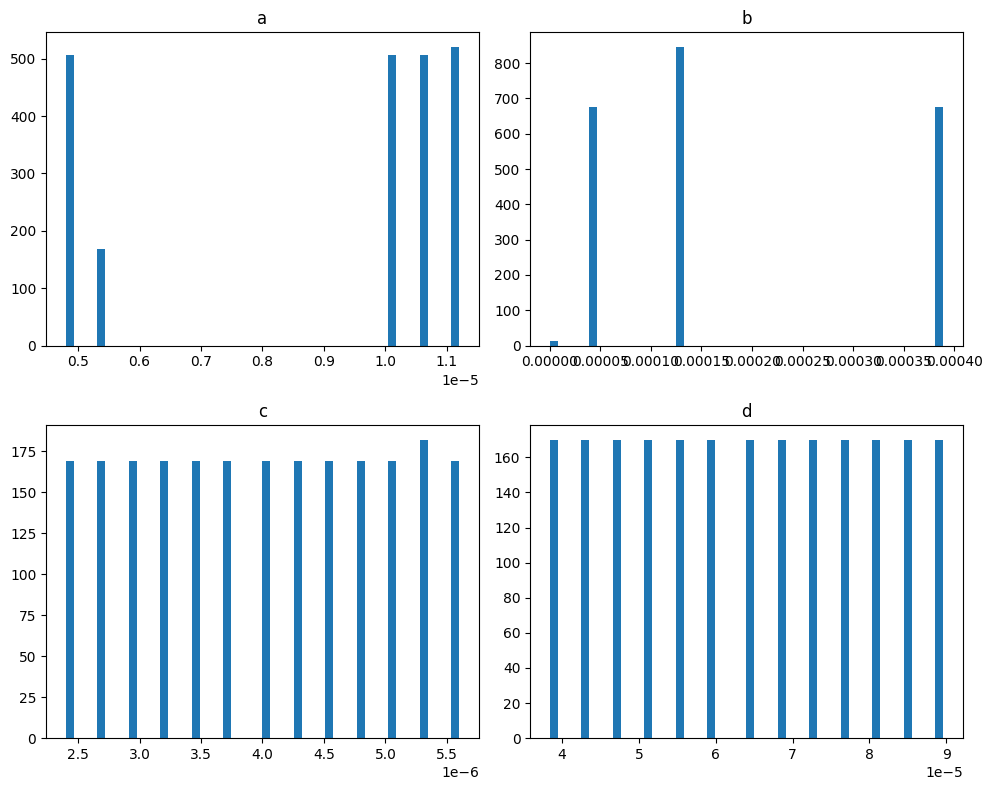

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(10,8))
axes = axes.flatten()

for i, col in enumerate(["a","b","c","d"]):
    axes[i].hist(df[col], bins=50)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()


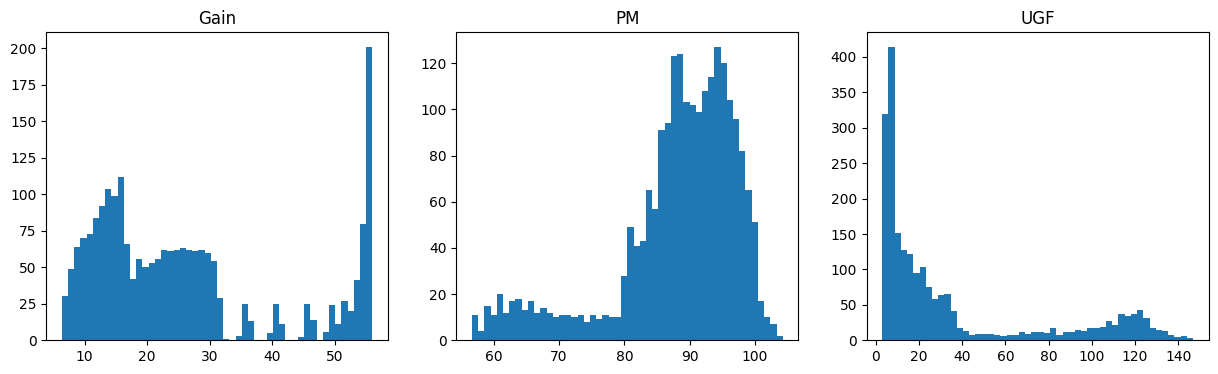

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

axes[0].hist(df["gain"], bins=50)
axes[0].set_title("Gain")

axes[1].hist(df["pm"], bins=50)
axes[1].set_title("PM")

axes[2].hist(df["ugf"], bins=50)
axes[2].set_title("UGF")

plt.show()


In [7]:
corr = df.corr()
corr[["gain","pm","ugf"]].loc[["a","b","c","d"]]


,gain,pm,ugf
a,0.012820,0.003150,0.019610
b,0.008498,0.002189,0.011205
c,0.322546,-0.385439,0.417955
d,0.246168,-0.344580,0.217055


In [8]:
df_log = df.copy()

for col in ["a","b","c","d"]:
    df_log[col] = np.log10(df[col])


d:\UST Project\UST_Analog_automation\ust\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
